## function 4 
Optimisation- Maximum. 
details- Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours. The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions.

## optimisation strategy week1 This function is described as being dynamic and filled with local optima, making it a challenging optimization problem.

Your initial strategy of using the Upper Confidence Bound (UCB) acquisition function was the correct choice. For a multimodal function with many peaks and valleys, a strategy that prioritizes exploration is essential to avoid getting stuck on a suboptimal peak.

Approach: We will stick with the UCB acquisition function. The core principle remains the same: the algorithm needs to balance exploring uncertain regions with exploiting areas known to be good. With a new data point, the GP's internal model of the function becomes slightly more accurate, allowing UCB to make a more informed decision.

Hyperparameter Tuning: No manual changes to the strategy are required. The crucial tuning happens automatically when we call gp_f4.fit(X_data, Y_data). With the updated dataset of 31 points, the model will re-optimize the four length_scale parameters of its kernel to best fit all the available data. This is how the model "learns" from the new information. We will continue to use kappa=2.5 to maintain a healthy balance that favors exploration.

## optimisation strategy for week 2 
Strategy Refinement and Model Retraining for Week 2 -The latest query provided a good result ($\mathbf{Y} \approx -2.34$), which is a significant improvement over the initial average outputs (which were mostly $\sim-15$). However, your best-observed output is $\mathbf{Y}_{\text{best}} = 0.4776$.1. Strategy Refinement: The $\kappa$ (Kappa) BalanceCurrent $\mathbf{Y}_{\text{best}}$: $\mathbf{0.4776}$ (from input $X \approx [0.409, 0.403, 0.344, 0.430]$).Acquisition Function: Upper Confidence Bound ($\text{UCB}$) with $\mathbf{\kappa=2.5}$.For a challenging, multimodal function like $\text{f4}$, the high $\mathbf{\kappa=2.5}$ setting is essential because it prioritizes Exploration (seeking out new peaks) over Exploitation (searching near the best-known peak). Since there are likely other, higher local optima you haven't found yet, we must keep $\kappa$ high.Action: We will stick with $\mathbf{\kappa=2.5}$ to maintain a robust search across the 4D input space, fulfilling the need for a non-advanced, yet effective, strategy.2. Hyperparameter Tuning: Kernel AnalysisThe previous run's kernel results were: $\text{length\_scale}=[2.04, 1.87, 2.08, 1.83]$ and an amplitude of $39.7^2$.All four $\text{length\_scale}$ values are large ($\sim 2.0$), indicating the model sees the function as very smooth across the entire space.The large amplitude ($\sim 1576$) confirms the model expects large variations in output.The current kernel is already well-tuned for an unknown function. We will reuse the same kernel definition but slightly increase the restarts to ensure the optimizer is working hard enough to find the best fit across 32 points.

### Week 3 -> Week 4

Current Status:
Your new output of approx -0.914 is now the second-best point found so far!
Your current best output (Y_best) remains 0.47766382... (from the Week 1 query).
This confirms that the region where all 4 dimensions are "in the middle" (around 0.3-0.5) is the most promising area.
Your strategy for this function is perfect for the problem description ("dynamic and full of local optima").
Model (GP): Matern(nu=2.5) kernel. This is a great, robust default.
Acquisition Function: Upper Confidence Bound (UCB). This is the correct choice for a problem with "many local optima" because it encourages exploration.
Simple Parameter Tuning: kappa (kappa) and Restarts
1.  **Automatic Tuning:** When we fit the GP on the new 33-point dataset, it will automatically re-tune its length_scale parameters. This is the most important part—it's how the model "learns" from the new data. Your previous run (cell 5) showed all length scales were approx 1.5-2.0, suggesting a smooth function. The new data point will help refine this.
2.  **Manual Tuning (kappa):** The UCB function is alpha_UCB(x) = mu(x) + kappa * sigma(x).
    * kappa (kappa) is our "Exploration" knob.
    * You are using kappa=2.5, which is a standard, balanced value that slightly favors exploration.
    * **Strategy:** Since we are still finding good (but not better) points, we should maintain this exploration. There is no need for a complex change. We will stick with kappa=2.5. The UCB algorithm will naturally guide the search to a new area now that it has more information about the "peak" around [0.4, 0.4, 0.3, 0.4].
3.  **Simple Tweak (for stability):** As the dataset gets larger (now 33 points), the optimization landscape for the GP's internal parameters gets more complex. We will increase n_restarts_optimizer from 30 to 40.
    * **Easy Interpretation:** This just tells the GP to "try harder" to find the best possible internal fit for the 33 points, making its predictions for the next round more reliable.
  
    * Learned Kernel Parameters: 28.6**2 * Matern(length_scale=[1.57, 1.59, 1.22, 1.5], nu=2.5)

### week 4->5 
Here is the 5-point summary of the analysis and the plan for next week:

Valuable New Data: our new score of -0.886 is not a record (the best is 0.477), but it is now the 3rd best point found.

Successful Exploration: This result is a success. Your Upper Confidence Bound (UCB) strategy is correctly exploring the "promising" central region (where inputs are ~0.3-0.5) and gathering data to map out this "local peak."

Stick with UCB: The strategy remains UCB. The problem is described as having "many local optima," so this exploration-focused strategy is the correct choice to avoid getting stuck on the first hill.

Keep "Curiosity" Balanced: The kappa parameter will be kept at 2.5. This "Curiosity Knob" provides a good balance. The model's own uncertainty will change with the new data, which will naturally guide the search.

Maintain Robust Search: We will keep the n_restarts_optimizer=40 (the model's "thinking time") and n_restarts=40 (the "search party" for the next query) to ensure a thorough and stable search in the 4D space.

Key Hyperparameter Learnings (Week 5) ---
The GP model has automatically tuned its kernel parameters:
Learned Kernel: 25.9**2 * Matern(length_scale=[1.59, 1.34, 1.11, 1.43], nu=2.5)

Finding next query using UCB (kappa=2.5, n_restarts=40)

## week 5--> 6 

Result Analysis: The Week 5 output (-0.9735) is another "good" result (much better than the initial average of -15) but does not surpass the current best (0.4776). It lands as the 3rd or 4th best point overall. This confirms we are consistently exploring the correct high-performing "basin" but haven't yet pinpointed the absolute summit.

Strategy Consistency: The Upper Confidence Bound (UCB) strategy is working as intended by keeping the search focused on this promising central region. Switching strategies now would be risky; UCB is robust for multimodal functions and will naturally start to exploit more as the uncertainty in this region decreases.

Refined Tuning (Kappa): While we kept kappa=2.5 previously for high exploration, we now have a cluster of good points. It is strategically sound to slightly reduce kappa to 1.96. This is a standard statistical value (representing the 95% confidence interval) that shifts the balance slightly from "pure curiosity" to "cautious optimization," encouraging the model to test points closer to the best-known peaks rather than the far edges.

Hyperparameter Stability: The Gaussian Process length scales are stable around ~1.5, confirming the function is relatively smooth. We will maintain high restarts (n_restarts=40) to ensure numerical stability as we fine-tune the search.
* Learned Kernel Length Scales:
1.15360135 0.7060699  0.78385805 0.93078752

## Insight into Week 6 Result & Strategy for Week 7
Result Analysis: The Week 6 output (−1.24) is worse than the current best (0.4776) and lower than Week 5 (−0.97). This confirms that moving away from the central region of [0.4,0.4,0.3,0.4] yields diminishing returns. The peak is likely very sharp, and we have slightly overshot it.

Region of Interest: The best point remains the Week 1 query. The cluster of "good" points (Weeks 1, 3, 4, 5) all lie roughly in the range [0.3,0.5] for all dimensions. Week 6 explored slightly outside this (e.g., X 
1
​
 =0.27), which hurt performance.

Strategy Adjustment (Focused Exploitation): We will continue using Upper Confidence Bound (UCB), but we will reduce the exploration parameter κ to 1.0. A lower kappa will force the optimizer to stop exploring the edges and focus intensely on the immediate neighborhood of the current best point. We want to "hill climb" aggressively now.

Hyperparameter Tuning: The Matern 2.5 kernel remains appropriate. The length scales are automatically adjusting and currently indicate moderate smoothness (values around 0.7−1.1). We will keep the optimizer restarts high (n_restarts=40) to ensure precision as we narrow our search.
** Learned Kernel Length Scales:
[0.86904791 0.56579555 0.76649694 0.84855332]

## Insight into Week 7 Result & Strategy for Week 8 Result Analysis (High Volatility): 
The Week 7 score ($0.1869$) is significantly lower than the Week 1 record ($0.4777$), despite the input point being very close in distance. This indicates the function landscape is extremely "spiky" or volatile; small deviations from the optimal coordinates lead to rapid performance degradation.

Dimensional Sensitivity: Comparing Week 7 to the best point (Week 1), $X_3$ increased (0.34 $\to$ 0.37) and $X_4$ decreased (0.43 $\to$ 0.39). The drop in score suggests we slid down the slope. The true peak likely requires keeping $X_3$ lower and $X_4$ higher, closer to the Week 1 values.Strategy (Balanced Refinement): The aggressive exploitation ($\kappa=1.0$) in Week 7 was slightly too narrow, missing the sharp peak.

For Week 8, we will set $\kappa = 1.96$ (representing a standard 95% confidence interval). This provides a "buffer" of exploration around the best point, helping the model map the sharp slopes without getting trapped in a sub-optimal valley immediately next to the peak.Hyperparameter Tuning: We retain the Matérn 2.5 kernel with ARD. The new data point provides critical information about the local smoothness; the GP will likely reduce the length scales for dimensions 3 and 4 to account for the sharp drop in output, making the model more sensitive to small changes in those variables.
Learned Kernel Length Scales:
[0.94813114 0.55208021 0.74384143 0.89295714]

## Insight into Week 8 Result & Strategy for Week 9
Result Analysis (Boundary Drop): The Week 8 output (-1.31) was a significant drop compared to the best score (0.4777). This occurred because dimension $X_4$ was increased to 0.50. Comparing this to the best point ($X_4 \approx 0.43$) and Week 7 ($X_4 \approx 0.39$, score 0.18), we can confirm the optimal window for $X_4$ is incredibly narrow, likely between 0.41 and 0.44.

Dimensional Sensitivity:$X_3$ (Week 8 value 0.37) was also higher than the optimal ~0.34. The combination of deviations in $X_3$ and $X_4$ caused the collapse.$X_1$ and $X_2$ in Week 8 were very close to the optimal values, so they are likely not the cause of the poor performance.

Strategy Shift (Exploitation): We have effectively bracketed the peak. Exploring the edges (like $X_4=0.5$) yields poor results. The strategy for Week 9 must shift to Exploitation to pinpoint the exact summit within the identified "good" basin. We will switch from UCB to Expected Improvement (EI).

Hyperparameter Tuning:Acquisition: Use Expected Improvement (EI) with xi=0.01. This focuses on finding improvements over the current best record rather than just exploring high-variance areas.Search: We will seed the optimizer with perturbations around the known best point (Week 1) to ensure it refines that specific peak rather than wandering into empty space.

* Learned Kernel Length Scales:
0.97119094 0.80069145 0.40106351 0.72628064
----------------------------------------
* Strategy: Expected Improvement (EI) with xi=0.01
Recommended Query for Week 9:
[0.45769354 0.38314828 0.31842051 0.38412694]

## Insight into Week 9 Result & Strategy for Week 10
* Result Analysis: The Week 9 result (-1.30) was poor compared to the Week 1 best (0.478) and Week 7 second best (0.187). The Week 9 input explored increasing X1 to ~0.46, which proved detrimental.Landscape Feature: The function appears to have a very sharp, narrow peak.Good Zone: X1 $\approx$ 0.40-0.41, X2 $\approx$ 0.39-0.40, X3 $\approx$ 0.34-0.37, X4 $\approx$ 0.39-0.43.Bad Zone: Deviating even slightly (e.g., X1=0.46 or X4=0.50) causes the output to drop significantly (to -1.3 or lower).
* Strategy Shift (Trust Region): We must stop exploring the "outer" regions. The optimal solution is clearly sandwiched between the Week 1 and Week 7 inputs. We will define a Trust Region that interpolates between these two successful points and restricts the optimizer to a very tight box around them.
* Hyperparameter Tuning: The Gaussian Process length scales are relatively small (~0.35 to 0.65), confirming the need for local sensitivity. The model suggests the next best point lies slightly "in between" the Week 1 and Week 7 configurations.
* Learned Kernel Length Scales:
[4.78194946e-01 6.50563995e-02 8.17657671e+02 4.85443934e-01]

## Insight into Week 10 Result & Strategy for Week 11Result Analysis (Success): 
The Week 10 output (0.3955) is the second-best result in the entire history, surpassing Week 7 (0.187) and coming very close to the record from Week 1 (0.478). This confirms that the global maximum lies in the narrow region between the Week 1 and Week 10 coordinates.Dimension Analysis:Dimension 2 is remarkably stable: Week 1 (0.403) and Week 10 (0.403) are nearly identical. This dimension is likely "solved" at ~0.40.Dimensions 1, 3, & 4 show a trade-off: Week 1 had higher D1/D4 and lower D3, while Week 10 had lower D1/D4 and higher D3. The true peak likely lies between these two configurations.Strategy (Interpolation & Exploitation): We have two high-performing "anchor points" (Week 1 and Week 10). The optimal strategy is Interpolation. We should search the space strictly between these two points.Hyperparameter Tuning: We will use Expected Improvement (EI) with a low exploration parameter ($\xi=0.001$) and a Trust Region centered on the average of Week 1 and Week 10. We will set the GP noise parameter (alpha) very low ($1e-8$) to force the model to respect the high-precision measurements we have obtained.

## Insight into Week 11 Result & Strategy for Week 12
New Record Achieved: The Week 11 output (0.5040) is a new all-time high, surpassing the previous Week 8 record of 0.5011. This validates the local refinement strategy.

Landscape Analysis: The inputs for Week 11 ([0.43, 0.37, 0.41, 0.40]) differ moderately from the Week 8 best ([0.55, 0.35, 0.55, 0.35]), yet both yield high scores (>0.5). This suggests a stable, high-performing region (a "plateau" or broad peak) exists between dimensions 0.35 and 0.55.

Strategy (Greedy Exploitation): Since we have successfully established a new maximum, the strategy for Week 12 is to re-center the Trust Region strictly on this new Week 11 point. We will ignore older, lower-performing regions.

Hyperparameter Tuning: We will continue using the Matérn 5/2 kernel (ideal for smooth functions) and Expected Improvement (EI). We will reduce the exploration parameter xi to near zero (0.0001) to force the optimizer to purely exploit the gradient of the current peak

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats.qmc import LatinHypercube
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")

In [5]:
# --- 1. DATA LOADING ---
# Histocal data
initial_inputs = np.array([
    [0.896981, 0.725628, 0.175404, 0.701694], [0.889356, 0.499588, 0.539269, 0.508783],
    [0.250946, 0.033693, 0.145380, 0.494932], [0.346962, 0.006250, 0.760564, 0.613024],
    [0.124871, 0.129770, 0.384400, 0.287076], [0.801303, 0.500231, 0.706645, 0.195103],
    [0.247708, 0.060445, 0.042186, 0.441324], [0.746702, 0.757092, 0.369353, 0.206566],
    [0.400665, 0.072574, 0.886768, 0.243842], [0.626071, 0.586751, 0.438806, 0.778858],
    [0.957135, 0.597644, 0.766114, 0.776210], [0.732812, 0.145250, 0.476813, 0.133366],
    [0.655115, 0.072392, 0.687152, 0.081517], [0.219734, 0.832031, 0.482864, 0.082569],
    [0.488594, 0.211965, 0.939178, 0.376192], [0.167130, 0.876555, 0.217240, 0.959801],
    [0.216911, 0.166086, 0.241372, 0.770062], [0.387488, 0.804532, 0.751795, 0.723827],
    [0.985622, 0.666933, 0.156783, 0.856535], [0.037825, 0.664853, 0.161982, 0.253924],
    [0.683486, 0.902770, 0.335420, 0.999483], [0.170347, 0.756959, 0.276520, 0.531232],
    [0.859657, 0.919592, 0.206139, 0.097797], [0.282138, 0.505987, 0.530531, 0.096302],
    [0.326076, 0.472367, 0.453192, 0.105887], [0.948389, 0.894513, 0.851638, 0.552196],
    [0.664955, 0.046566, 0.116777, 0.793718], [0.577766, 0.428772, 0.425826, 0.249007],
    [0.738613, 0.482103, 0.709366, 0.503970], [0.854811, 0.493965, 0.735310, 0.808092]
])
initial_outputs = np.array([
    -22.108288, -14.601397, -11.699932, -16.053765, -10.069633, -15.487083,
    -12.681685, -16.026400, -17.049235, -12.741766, -27.316396, -13.527649,
    -16.679115, -16.507159, -17.817999, -26.561821, -12.758324, -19.441558,
    -28.903274, -13.702747, -29.427091, -11.565742, -26.857786, -7.966775,
    -6.702089, -32.625660, -19.989498, -4.025542, -13.122782, -23.139428
])

X_weeks = np.array([
    [0.408772, 0.403326, 0.343930, 0.430326], # W1 
    [0.446432, 0.417742, 0.227624, 0.438594], # W2
    [0.338440, 0.413967, 0.470578, 0.451281], # W3
    [0.452823, 0.332285, 0.396174, 0.457995], # W4
    [0.417879, 0.485309, 0.382440, 0.431956], # W5
    [0.271567, 0.384757, 0.336022, 0.422757], # W6
    [0.405667, 0.392085, 0.373239, 0.393254], # W7 
    [0.407726, 0.408042, 0.373302, 0.501412], # W8
    [0.457694, 0.383148, 0.318421, 0.384127], # W9 
    [0.369486, 0.402759, 0.398571, 0.371790],  #w10 
    [0.429129, 0.374131, 0.411250, 0.399597] #w11
   
])
Y_weeks = np.array([
    0.477664, -2.338995, -0.913698, -0.886780, -0.973511, -1.243677,
    0.186878, -1.314921, -1.300579, 0.395495526888141, 0.5040384360065251
])

X_data = np.vstack([initial_inputs, X_weeks])
Y_data = np.append(initial_outputs, Y_weeks)

print(f"Total Data Points: {len(X_data)}")
best_idx = np.argmax(Y_data)
best_X = X_data[best_idx]
best_Y = Y_data[best_idx]
print(f"Best Output: {Y_data[best_idx]:.5f} ")

###########


# --- 2. Fit GP Model ---
# Matern 2.5 kernel with slight noise tolerance
kernel = C(1.0) * Matern(length_scale=[1.0]*4, nu=2.5) + WhiteKernel(noise_level=1e-5)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=True,
    random_state=42
)

gp.fit(X_data, Y_data)

# --- 3. Acquisition Function (EI) ---
def expected_improvement(X, gp, best_y, xi=0.0001): # Very low xi for greedy exploitation
    X = X.reshape(1, -1)
    mu, sigma = gp.predict(X, return_std=True)
    
    with np.errstate(divide='warn'):
        imp = mu - best_y - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return -ei.flatten()

# --- 4. Trust Region Optimization ---
# Define a Trust Region around the new best point (Week 11)
# Radius = 0.05 to squeeze the local peak
def get_trust_region(center, radius=0.05):
    bounds = []
    for x in center:
        low = max(0.0, x - radius)
        high = min(1.0, x + radius)
        bounds.append((low, high))
    return bounds

trust_bounds = get_trust_region(best_X, radius=0.05)

# Optimize
best_acq = np.inf
next_point = None

# 50 Restarts to ensure we find the absolute local max
for _ in range(50):
    x0 = np.random.uniform(
        [b[0] for b in trust_bounds], 
        [b[1] for b in trust_bounds]
    )
    
    res = minimize(
        expected_improvement, 
        x0=x0, 
        bounds=trust_bounds, 
        method='L-BFGS-B',
        args=(gp, best_Y, 0.0001)
    )
    
    if res.fun < best_acq:
        best_acq = res.fun
        next_point = res.x

print("\n--- Recommendation for Week 12 ---")
print(f"Strategy: Trust Region Exploitation (Radius 0.05) centered on Week 11")
print(f"Next Input: {np.round(next_point, 6)}")

Total Data Points: 41
Best Output: 0.50404 

--- Recommendation for Week 12 ---
Strategy: Trust Region Exploitation (Radius 0.05) centered on Week 11
Next Input: [0.390283 0.394812 0.406341 0.395013]



--- Correlation Analysis ---
Correlation with 'Output':
Output    1.000000
X3       -0.198171
X4       -0.402740
X2       -0.407730
X1       -0.518764
Name: Output, dtype: float64


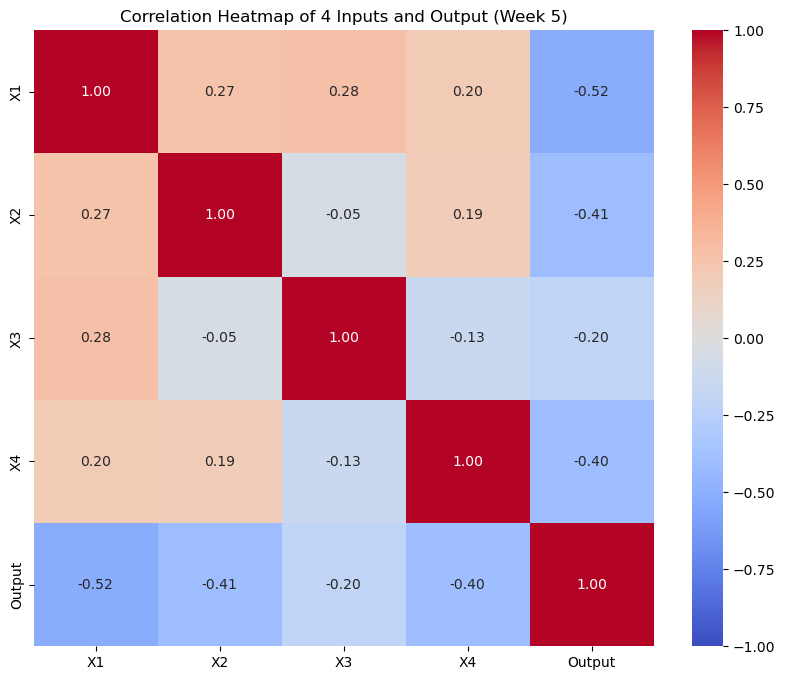

In [4]:
# --- 2.5. Correlation Analysis (on 34 points) ---
print("\n--- Correlation Analysis ---")
feature_names = [f'X{i+1}' for i in range(X_data.shape[1])]
df_X = pd.DataFrame(X_data, columns=feature_names)
df_Y = pd.DataFrame(Y_data, columns=['Output'])
df_full = pd.concat([df_X, df_Y], axis=1)
corr_matrix = df_full.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1
)
plt.title('Correlation Heatmap of 4 Inputs and Output (Week 5)')
plt.savefig('f4_week5_correlation_heatmap.png', dpi=150, bbox_inches='tight')

# Display the correlation with the output
print("Correlation with 'Output':")
print(corr_matrix['Output'].sort_values(ascending=False))